Importing libraries

In [122]:
import pandas as pd
import numpy as np

Loading and Exploring the Dataset

In [123]:
crop = pd.read_csv("C:\\Learning\\Python_proj\\Crop_Recommendation\\Crop_recommendation.csv")
crop.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


Dimensionality of Dataframe

In [124]:
crop.shape

(2200, 8)

Type of data present in each of the columns present in the dataset

In [125]:
crop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


Statistical Summary of the Dataset

In [126]:
crop.describe().T

,count,mean,std,min,25%,50%,75%,max
N,2200.0,50.551818,36.917334,0.000000,21.000000,37.000000,84.250000,140.000000
P,2200.0,53.362727,32.985883,5.000000,28.000000,51.000000,68.000000,145.000000
K,2200.0,48.149091,50.647931,5.000000,20.000000,32.000000,49.000000,205.000000
temperature,2200.0,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.0,71.481779,22.263812,14.258040,60.261953,80.473146,89.948771,99.981876
ph,2200.0,6.469480,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.0,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117


Exploratory Data Analysis

In [127]:
# check the number of null values in the dataset columns wise
crop.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [128]:
## check the number of duplicate values in the dataset columns wise
crop.duplicated().sum()

np.int64(0)

Compute pairwse corelation of coloumns

In [129]:
numeric_df = crop.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

In [130]:
corr_matrix.corr()

,N,P,K,temperature,humidity,ph,rainfall
N,1.000000,-0.629480,-0.551014,0.012913,0.192853,0.147984,0.019757
P,-0.629480,1.000000,0.921035,-0.444387,-0.374212,-0.417487,-0.263861
K,-0.551014,0.921035,1.000000,-0.479673,-0.077174,-0.491186,-0.267833
temperature,0.012913,-0.444387,-0.479673,1.000000,0.226292,-0.071122,-0.143422
humidity,0.192853,-0.374212,-0.077174,0.226292,1.000000,-0.194134,-0.008109
ph,0.147984,-0.417487,-0.491186,-0.071122,-0.194134,1.000000,-0.289705
rainfall,0.019757,-0.263861,-0.267833,-0.143422,-0.008109,-0.289705,1.000000


Import seaborn library to draw heatmap

<Axes: >

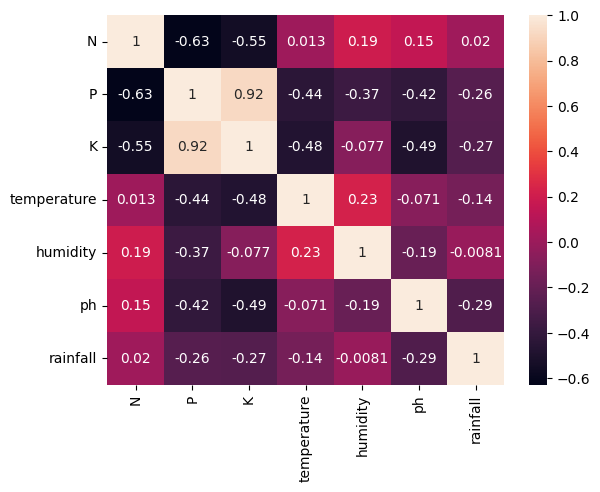

In [131]:
import seaborn as sns
sns.heatmap(corr_matrix.corr(), annot=True, cbar=True)

In [132]:
crop.label.value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

In [133]:
crop['label'].unique().size

22

Import library to Plot Feature statistics

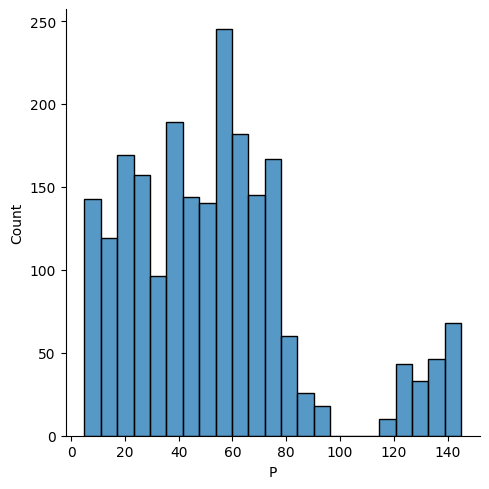

In [134]:
import matplotlib.pyplot as plt
sns.displot(crop['P'])
plt.show()

C:\Users\H193156\AppData\Local\Temp\ipykernel_22068\1039284138.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(crop['K'])


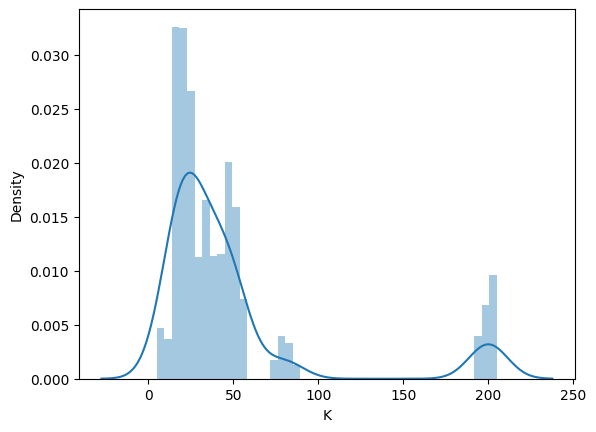

In [135]:
import matplotlib.pyplot as plt
sns.distplot(crop['K'])
plt.show()

In [136]:
crop.label.unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

Create dictionary to store crop items

In [137]:
crop_dict={
    'rice' : 1,
    'maize' : 2,
    'chickpea' : 3,
    'kidneybeans' : 4,
    'pigeonpeas' : 5,
    'mothbeans' : 6,
    'mungbean' : 7,
    'blackgram' : 8,
    'lentil' : 9,
    'pomegranate' : 10,
    'banana' : 11,
    'mango' : 12,
    'grapes' : 13,
    'watermelon' : 14,
    'muskmelon' : 15,
    'apple' : 16,
    'orange' : 17,
    'papaya' : 18,
    'coconut' : 19,
    'cotton' : 20,
    'jute' : 21,
    'coffee' : 22
}
crop['label'] = crop['label'].map(crop_dict)

In [138]:
crop.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,1
1,85,58,41,21.770462,80.319644,7.038096,226.655537,1
2,60,55,44,23.004459,82.320763,7.840207,263.964248,1
3,74,35,40,26.491096,80.158363,6.980401,242.864034,1
4,78,42,42,20.130175,81.604873,7.628473,262.717340,1


In [139]:
crop.label.unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22])

In [140]:
crop.label.value_counts()

label
1     100
2     100
3     100
4     100
5     100
6     100
7     100
8     100
9     100
10    100
11    100
12    100
13    100
14    100
15    100
16    100
17    100
18    100
19    100
20    100
21    100
22    100
Name: count, dtype: int64

Model Development

Let's prepare our data for training and splitting it into training and validation data so, that we can select which model's performance is best as per the use case. We will train some of the state of the art machine learning classification models and then select best out of them using validation data.

In [141]:
# Segregate features and target variable from Dataset
X=crop.drop('label', axis = 1)
Y=crop['label']

In [142]:
X.head()

,N,P,K,temperature,humidity,ph,rainfall
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,226.655537
2,60,55,44,23.004459,82.320763,7.840207,263.964248
3,74,35,40,26.491096,80.158363,6.980401,242.864034
4,78,42,42,20.130175,81.604873,7.628473,262.717340


In [143]:
Y.head()

0    1
1    1
2    1
3    1
4    1
Name: label, dtype: int64

After segregating features and the target variable from the dataset we will split it into 80:20 ratio for model selection

In [144]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [145]:
X_train.shape

(1760, 7)

Normalising the data before training help us to achieve stable and fast training of the model.

In [146]:
from sklearn.preprocessing import MinMaxScaler
mx = MinMaxScaler()
X_train = mx.fit_transform(X_train)
X_test = mx.transform(X_test)

In [147]:
X_train

array([[0.12142857, 0.07857143, 0.045     , ..., 0.9089898 , 0.48532225,
        0.29685161],
       [0.26428571, 0.52857143, 0.07      , ..., 0.64257946, 0.56594073,
        0.17630752],
       [0.05      , 0.48571429, 0.1       , ..., 0.57005802, 0.58835229,
        0.08931844],
       ...,
       [0.07857143, 0.22142857, 0.13      , ..., 0.43760347, 0.46198144,
        0.28719815],
       [0.07857143, 0.85      , 0.995     , ..., 0.76763665, 0.44420505,
        0.18346657],
       [0.22857143, 0.52142857, 0.085     , ..., 0.56099735, 0.54465022,
        0.11879596]], shape=(1760, 7))

In [148]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
sc.fit(X_train)
X_train = sc.transform(X_train)
X_test = sc.transform(X_test)

Import libraries

In [149]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score

In [150]:
models = {
    'LogisticRegression' : LogisticRegression(),
    'GaussianNB' : GaussianNB(),
    'SVC' : SVC(),
    'KNeighborsClassifier' : KNeighborsClassifier(),
    'DecisionTreeClassifier' : DecisionTreeClassifier(),
    'ExtraTreeClassifier' : ExtraTreeClassifier(),
    'RandomForestClassifier' : RandomForestClassifier(),
    'BaggingClassifier' : BaggingClassifier(),
    'GradientBoostingClassifier' : GradientBoostingClassifier(),
    'AdaBoostClassifier' : AdaBoostClassifier()
}

In [151]:
for name, model in models.items():
    model.fit(X_train, Y_train)
    y_pred = model.predict(X_test)
    score = accuracy_score(Y_test, y_pred)
    print(f"{name} model with accuracy score :{score}")

LogisticRegression model with accuracy score :0.9636363636363636
GaussianNB model with accuracy score :0.9954545454545455
SVC model with accuracy score :0.9681818181818181
KNeighborsClassifier model with accuracy score :0.9659090909090909
DecisionTreeClassifier model with accuracy score :0.9863636363636363
ExtraTreeClassifier model with accuracy score :0.9022727272727272
RandomForestClassifier model with accuracy score :0.9931818181818182
BaggingClassifier model with accuracy score :0.990909090909091
GradientBoostingClassifier model with accuracy score :0.9818181818181818
AdaBoostClassifier model with accuracy score :0.14545454545454545


Model Evaluation

From the above accuracies we can say that GaussianNB and RandomForestClassifier classifier performing better on the validation data with less difference between the validation and training data.

Let's use RandomForestClassifier model with accuracy score :0.9931818181818182

In [152]:
randclf = RandomForestClassifier()
randclf.fit(X_train, Y_train)
y_pred = randclf.predict(X_test)
accuracy_score(Y_test, y_pred)


0.9931818181818182

In [153]:
crop.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

Write a function to return prediction to the caller (User interface)

In [154]:
def recommendation(N, P, K, temperature, humidity, ph, rainfall):
    features = np.array([[N, P, K, temperature, humidity, ph, rainfall]])
    mx_features =mx.fit_transform(features)
    sc_mx_features = sc.transform(mx_features)
    prediction = randclf.predict(sc_mx_features)
    return prediction[0]

In [155]:
crop.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,1
1,85,58,41,21.770462,80.319644,7.038096,226.655537,1
2,60,55,44,23.004459,82.320763,7.840207,263.964248,1
3,74,35,40,26.491096,80.158363,6.980401,242.864034,1
4,78,42,42,20.130175,81.604873,7.628473,262.717340,1


Test with random values

In [156]:
N=90
P=42
K=43
temperature=20.879744
humidity=82.002744
ph=6.502985
rainfall=2202.935536

predict =  recommendation(N, P, K, temperature, humidity, ph, rainfall)

In [157]:
predict

np.int64(15)

Generate PKL files to be used from the caller (User interface)

In [158]:
import pickle
pickle.dump(randclf, open('model.pkl', 'wb'))
pickle.dump(mx, open('minmaxscaler.pkl', 'wb'))
pickle.dump(sc, open('standscaler.pkl', 'wb'))